In [1]:
## **課題１**

# 授業中に紹介したSKABデータについてXGBoostを用いてモデル構築を行い，
# RandomForestの変数重要度，SHAP値と比較してどのような違いがあるか検証を行え．
# また，可能であればSVMなど他の予測モデルで予測を行った結果と比較を行い，
# 予測に効く変数が検討したモデルでどのように異なるか考察を行え．

## **課題２**

# 自分の興味のあるデータ（対象は何でも良いが回帰の問題をおすすめする：SHAPバージョンによるトラブルを避けるため）について今回と同様のRandomForestやSHAP値による解析を行い，
# 対象のデータの予測に効く変数がどのようなものか，またそこからどのようなことが考察できるのか（どのような現象が発生しているか？など）について考察を行え

In [6]:
%pip install xgboost
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 11.2 MB/s  0:00:00

   ------------- -------------------------- 1/3 [cloudpickle]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   ---------------------------------------- 3/3 [shap]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\yuema\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\yuema\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:04:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\yuema\AppData\Local\Temp\ipykernel_1660\3305360211.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_imp.values, y=xgb_imp.index, ax=axes[0], palette='viridis')
C:\Users\yuema\AppData\Local\Temp\ipykernel_1660\3305360211.py:82: FutureWarning: 

Passing `palette` wit

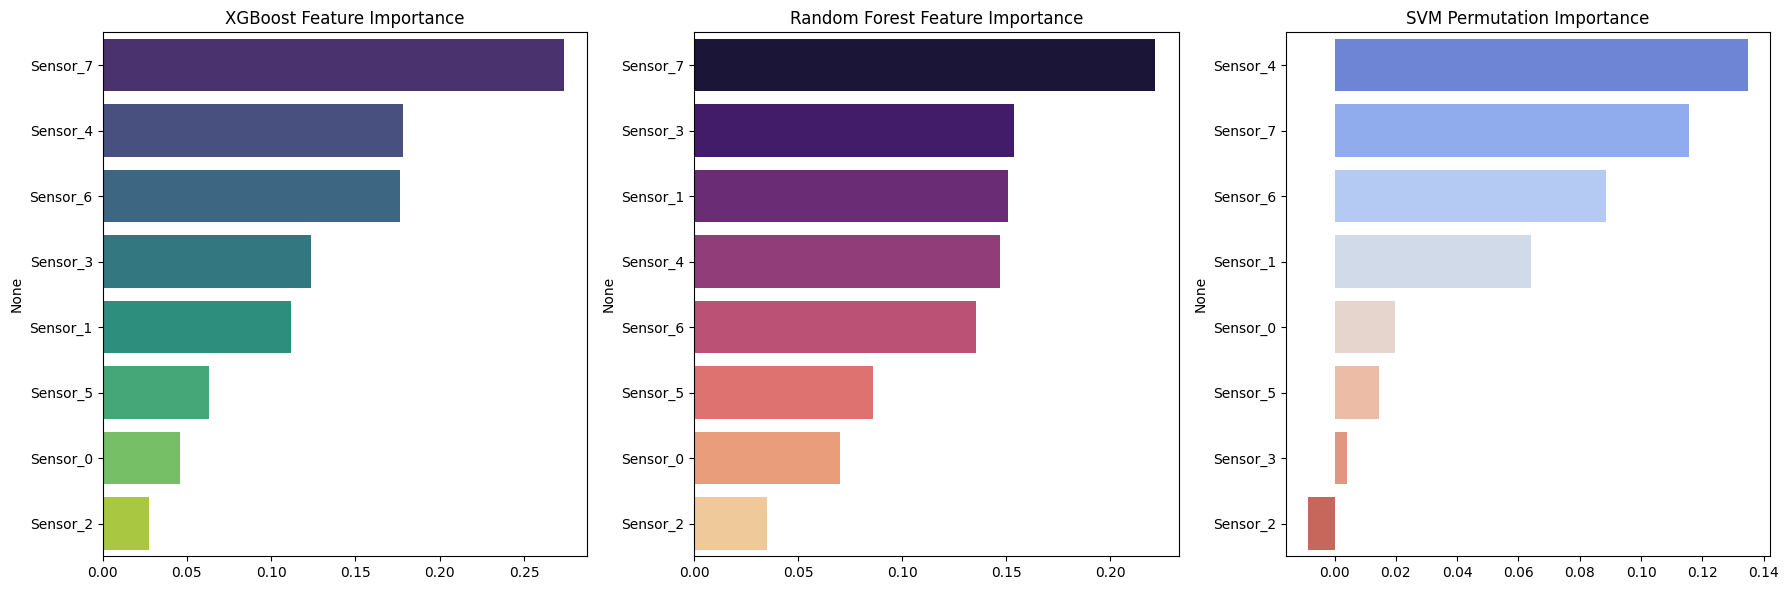

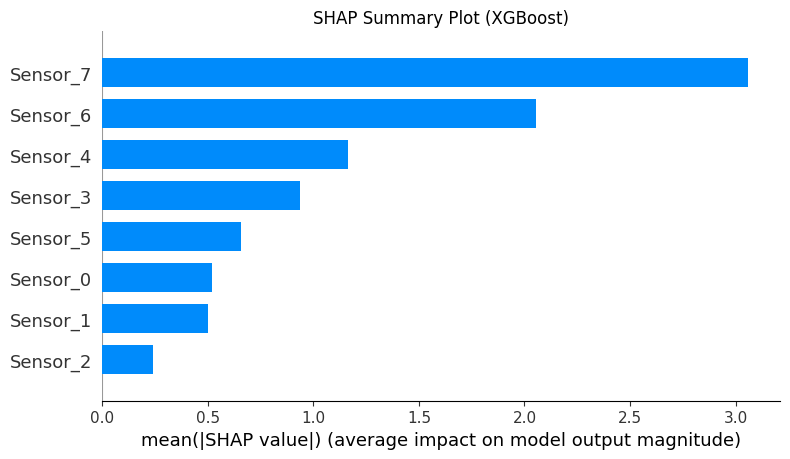

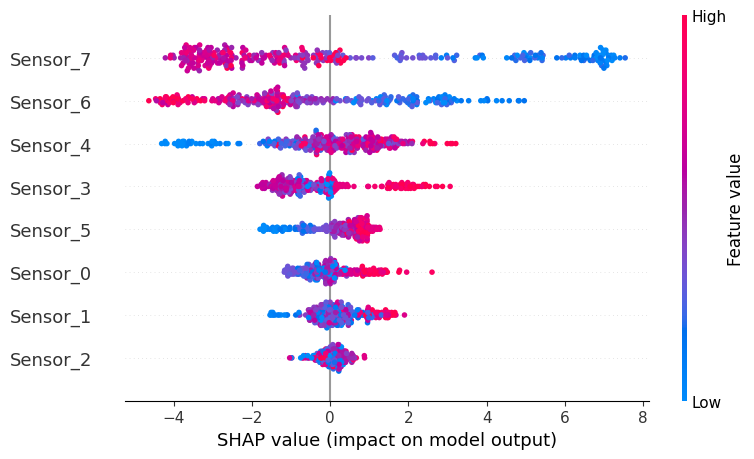

In [7]:
# 課題1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import shap

# --- 1. データ準備 (SKABデータの読み込み) ---
# ※ここでは例としてcsvを読み込む形にしています。実際のファイルパスに合わせてください。
# SKABは通常、時系列データですが、ここでは変数重要度を見るために
# 各時点を独立したサンプルとみなして「正常(0) vs 異常(1)」の分類問題として扱います。

# data = pd.read_csv('skab_data.csv', sep=';') 
# 以下の変数は適宜データフレームに合わせて変更してください
# X = data.drop(['anomaly', 'datetime'], axis=1) # 説明変数
# y = data['anomaly'] # 目的変数 (0:正常, 1:異常)

# --- ダミーデータ生成（動作確認用：実際には上記でSKABデータを読み込んでください）---
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=8, n_informative=5, n_redundant=2, random_state=42)
feature_names = [f'Sensor_{i}' for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)
# -------------------------------------------------------------------------

# 訓練データとテストデータの分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# スケーリング (SVM等で必要)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names)

# --- 2. モデル構築 & 学習 ---

# (A) XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# (B) Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# (C) SVM (RBFカーネル)
# SVMは線形ではないため、変数重要度を直接出す属性(coef_)がない(線形SVMならある)。
# そのため、後ほどPermutation Importanceで評価する。
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# --- 3. 変数重要度 & SHAP値の算出 ---

# 1. XGBoost Feature Importance (Gain)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False)

# 2. Random Forest Feature Importance (Gini Impurity reduction)
rf_imp = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

# 3. SVM Permutation Importance
# (ある変数をランダムにシャッフルした時にどれだけ精度が落ちるか＝重要度)
perm_importance = permutation_importance(svm_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
svm_imp = pd.Series(perm_importance.importances_mean, index=feature_names).sort_values(ascending=False)

# 4. SHAP Values (XGBoostモデルに対して計算)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# --- 4. 結果の可視化 ---

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost Plot
sns.barplot(x=xgb_imp.values, y=xgb_imp.index, ax=axes[0], palette='viridis')
axes[0].set_title('XGBoost Feature Importance')

# Random Forest Plot
sns.barplot(x=rf_imp.values, y=rf_imp.index, ax=axes[1], palette='magma')
axes[1].set_title('Random Forest Feature Importance')

# SVM Plot
sns.barplot(x=svm_imp.values, y=svm_imp.index, ax=axes[2], palette='coolwarm')
axes[2].set_title('SVM Permutation Importance')

plt.tight_layout()
plt.show()

# SHAP Summary Plot
plt.figure()
plt.title("SHAP Summary Plot (XGBoost)")
shap.summary_plot(shap_values, X_test, plot_type="bar") # barで全体的な重要度を表示
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_test) # beeswarmで方向性も表示